In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


data = pd.read_csv('Data/numerical_train_cleaned.csv')
X = data.drop('SalePrice', axis=1)
y = data['SalePrice']

data

,GrLivArea,1stFlrSF,2ndFlrSF,TotalBsmtSF,BsmtUnfSF,BsmtFinSF1,BsmtFinSF2,LotArea,LotFrontage,GarageArea,...,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,SalePrice
0,1710,856,854,856,150,706,0,8450,65.0,548,...,1,0,2,1,3,1,8,0,2,208500
1,1262,1262,0,1262,284,978,0,9600,80.0,460,...,0,1,2,0,3,1,6,1,2,181500
2,1786,920,866,920,434,486,0,11250,68.0,608,...,1,0,2,1,3,1,6,1,2,223500
3,1717,961,756,756,540,216,0,9550,60.0,642,...,1,0,1,0,3,1,7,1,3,140000
4,2198,1145,1053,1145,490,655,0,14260,84.0,836,...,1,0,2,1,4,1,9,1,3,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1407,1647,953,694,953,953,0,0,7917,62.0,460,...,0,0,2,1,3,1,7,1,2,175000
1408,2073,2073,0,1542,589,790,163,13175,85.0,500,...,1,0,2,0,3,1,7,2,2,210000
1409,2340,1188,1152,1152,877,275,0,9042,66.0,252,...,0,0,2,0,4,1,9,2,1,266500
1410,1078,1078,0,1078,0,49,1029,9717,68.0,240,...,1,0,1,0,2,1,5,0,1,142125


# Mutal Information score and Correlation
for feature reduction

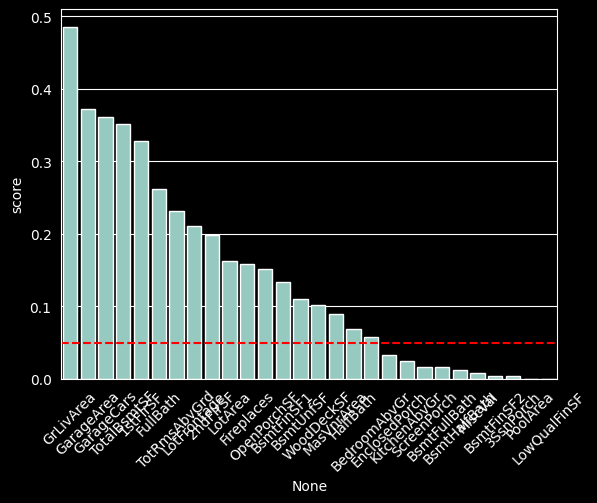

In [3]:
from sklearn.feature_selection import mutual_info_regression

mi = mutual_info_regression(X, y)
mi_series = pd.Series(mi, index=X.columns, name='score').sort_values(ascending=False)

sns.barplot(x=mi_series.index, y=mi_series.sort_values(ascending=False))
plt.xticks(rotation=45)
plt.axhline(y=0.05, color='r', linestyle='--')
plt.show()

In [4]:
selected_X = X[mi_series[mi_series.values > 0.05].keys()]

selected_X

,GrLivArea,GarageArea,GarageCars,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,LotFrontage,2ndFlrSF,LotArea,Fireplaces,OpenPorchSF,BsmtFinSF1,BsmtUnfSF,WoodDeckSF,MasVnrArea,HalfBath,BedroomAbvGr
0,1710,548,2,856,856,2,8,65.0,854,8450,0,61,706,150,0,196.0,1,3
1,1262,460,2,1262,1262,2,6,80.0,0,9600,1,0,978,284,298,0.0,0,3
2,1786,608,2,920,920,2,6,68.0,866,11250,1,42,486,434,0,162.0,1,3
3,1717,642,3,756,961,1,7,60.0,756,9550,1,35,216,540,0,0.0,0,3
4,2198,836,3,1145,1145,2,9,84.0,1053,14260,1,84,655,490,192,350.0,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1407,1647,460,2,953,953,2,7,62.0,694,7917,1,40,0,953,0,0.0,1,3
1408,2073,500,2,1542,2073,2,7,85.0,0,13175,2,0,790,589,349,119.0,0,3
1409,2340,252,1,1152,1188,2,9,66.0,1152,9042,2,60,275,877,0,0.0,0,4
1410,1078,240,1,1078,1078,1,5,68.0,0,9717,0,0,49,0,366,0.0,0,2
